# FAPE — Folktables ACS EDA
## Socioeconomic Domain — Income Fairness Analysis

**Dataset:** US Census American Community Survey 2021  
**Records:** 1,589,032 across all 50 states  
**Target:** Annual income > $50,000  
**Domain:** Socioeconomic  

Exploratory analysis of demographic distributions, income inequality patterns,
and fairness-relevant signals before baseline model training.


In [1]:
import sys
import os
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import load_folktables_acs

# Plot settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Census code mappings
RACE_LABELS = {
    1: "White",
    2: "Black/African-American",
    3: "American Indian",
    4: "Alaska Native",
    5: "AI + AN",
    6: "Asian",
    7: "NH/Pacific Islander",
    8: "Other",
    9: "Two or more"
}
SEX_LABELS = {1: "Male", 2: "Female"}

print("Imports complete")


Imports complete


In [2]:
df = load_folktables_acs()
df['race_label'] = df['RAC1P'].map(RACE_LABELS)
df['sex_label'] = df['SEX'].map(SEX_LABELS)
print(f"Shape: {df.shape}")
print(f"Income >$50k rate: {df['label'].mean():.1%}")


Loading Folktables ACS data — first run downloads per state, please wait...


  AL: 22,161 records
  AK: 3,225 records


  AZ: 33,766 records


  AR: 13,364 records


  CA: 189,413 records


...

  TX: 126,247 records


  UT: 17,039 records
  VT: 3,401 records


  VA: 44,403 records


  WA: 39,254 records
  WV: 7,359 records


  WI: 31,220 records
  WY: 2,886 records
Folktables ACS loaded: 1,589,032 records, income >$50k rate: 42.8%
Shape: (1589032, 13)
Income >$50k rate: 42.8%


## 1. Label Distribution

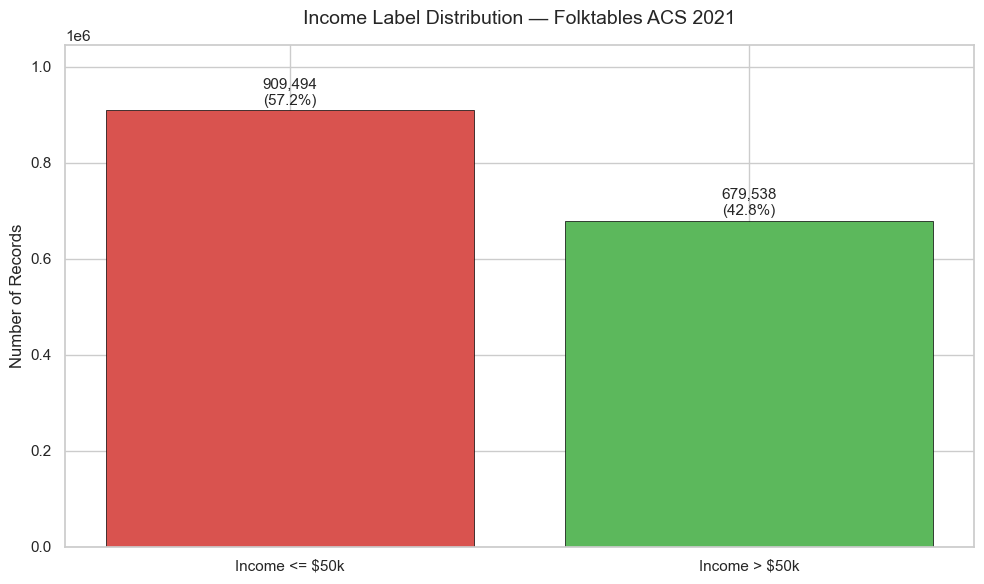

Class imbalance ratio: 1.34:1


In [3]:
fig, ax = plt.subplots()
label_counts = df['label'].value_counts().sort_index()
bars = ax.bar(['Income <= $50k', 'Income > $50k'], label_counts.values,
              color=['#d9534f', '#5cb85c'], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{val:,}\n({val/len(df):.1%})', ha='center', va='bottom', fontsize=11)
ax.set_title('Income Label Distribution — Folktables ACS 2021', fontsize=14, pad=15)
ax.set_ylabel('Number of Records')
ax.set_ylim(0, max(label_counts.values) * 1.15)
plt.tight_layout()
plt.savefig('../figures/eda/folktables_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Class imbalance ratio: {label_counts[0]/label_counts[1]:.2f}:1")


## 2. Race Distribution and Income Rate

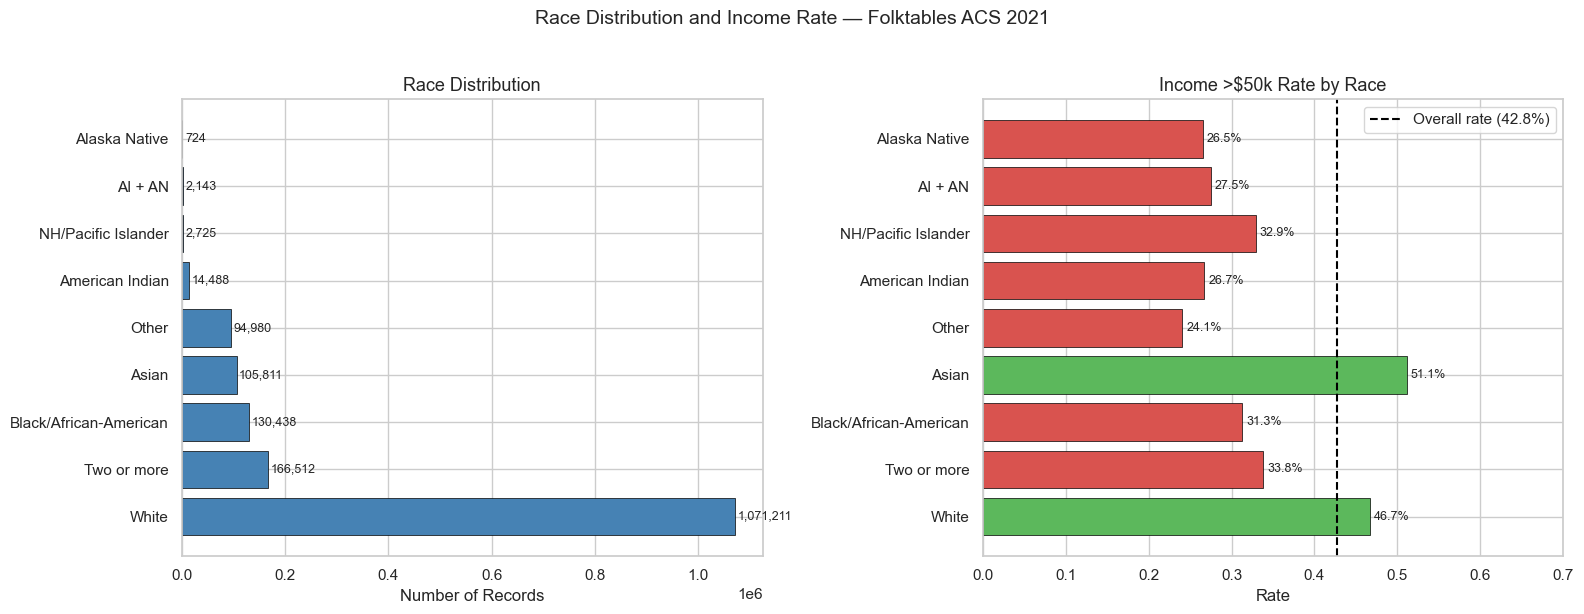

Race gap (White - Black): 15.4%


In [4]:
race_stats = df.groupby('race_label').agg(
    count=('label', 'count'),
    income_rate=('label', 'mean')
).reset_index().sort_values('count', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Count plot
bars = ax1.barh(race_stats['race_label'], race_stats['count'],
                color='steelblue', edgecolor='black', linewidth=0.5)
ax1.set_title('Race Distribution', fontsize=13)
ax1.set_xlabel('Number of Records')
for bar, val in zip(bars, race_stats['count']):
    ax1.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

# Income rate plot
colors = ['#d9534f' if r < 0.40 else '#f0ad4e' if r < 0.45 else '#5cb85c'
          for r in race_stats['income_rate']]
bars2 = ax2.barh(race_stats['race_label'], race_stats['income_rate'],
                 color=colors, edgecolor='black', linewidth=0.5)
ax2.axvline(x=df['label'].mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Overall rate ({df["label"].mean():.1%})')
ax2.set_title('Income >$50k Rate by Race', fontsize=13)
ax2.set_xlabel('Rate')
ax2.set_xlim(0, 0.7)
ax2.legend()
for bar, val in zip(bars2, race_stats['income_rate']):
    ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', fontsize=9)

plt.suptitle('Race Distribution and Income Rate — Folktables ACS 2021', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/folktables_race_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

white_rate = df[df['RAC1P']==1]['label'].mean()
black_rate = df[df['RAC1P']==2]['label'].mean()
print(f"Race gap (White - Black): {abs(white_rate - black_rate):.1%}")


## 3. Sex Distribution and Income Rate

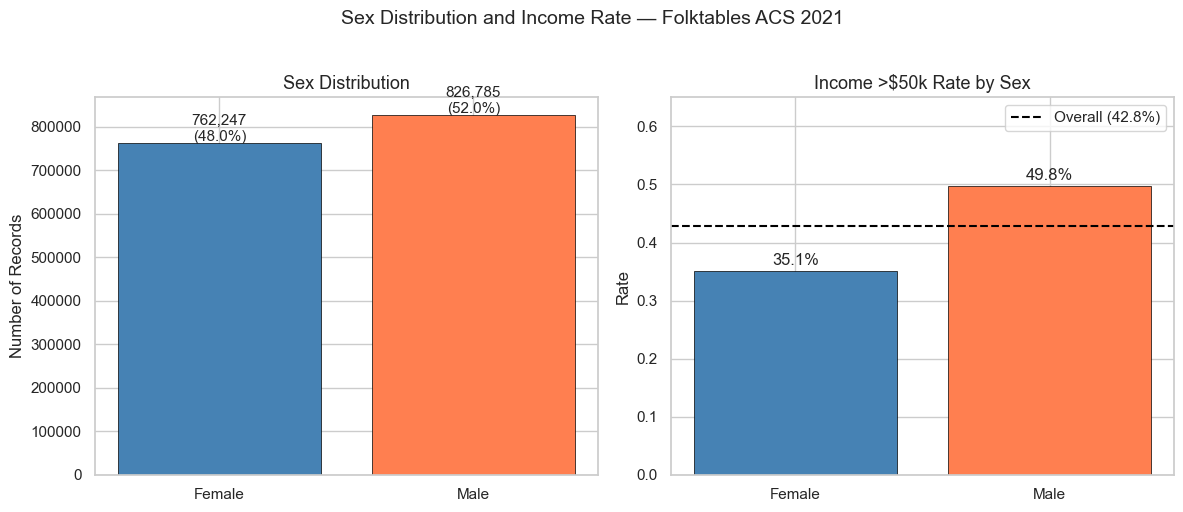

Sex gap (Male - Female): 14.6%


In [5]:
sex_stats = df.groupby('sex_label').agg(
    count=('label', 'count'),
    income_rate=('label', 'mean')
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(sex_stats['sex_label'], sex_stats['count'],
        color=['steelblue', 'coral'], edgecolor='black', linewidth=0.5)
ax1.set_title('Sex Distribution', fontsize=13)
ax1.set_ylabel('Number of Records')
for i, (_, row) in enumerate(sex_stats.iterrows()):
    ax1.text(i, row['count'] + 5000, f'{row["count"]:,}\n({row["count"]/len(df):.1%})',
             ha='center', fontsize=11)

ax2.bar(sex_stats['sex_label'], sex_stats['income_rate'],
        color=['steelblue', 'coral'], edgecolor='black', linewidth=0.5)
ax2.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Overall ({df["label"].mean():.1%})')
ax2.set_title('Income >$50k Rate by Sex', fontsize=13)
ax2.set_ylabel('Rate')
ax2.set_ylim(0, 0.65)
ax2.legend()
for i, (_, row) in enumerate(sex_stats.iterrows()):
    ax2.text(i, row['income_rate'] + 0.01, f'{row["income_rate"]:.1%}',
             ha='center', fontsize=12)

plt.suptitle('Sex Distribution and Income Rate — Folktables ACS 2021', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/folktables_sex_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

male_rate = df[df['SEX']==1]['label'].mean()
female_rate = df[df['SEX']==2]['label'].mean()
print(f"Sex gap (Male - Female): {abs(male_rate - female_rate):.1%}")


## 4. Age Distribution

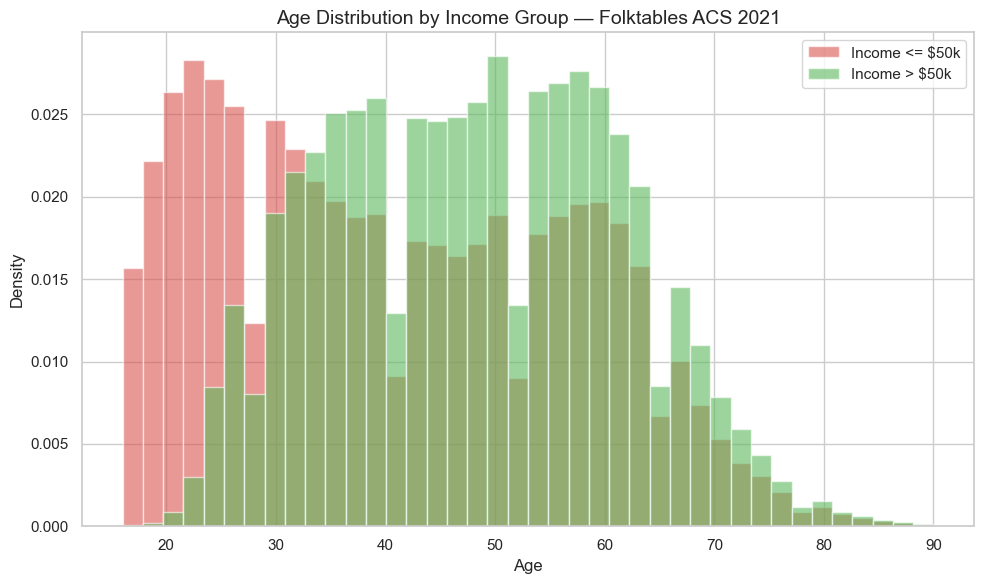

Mean age: 44.0 | Median: 44.0


In [6]:
fig, ax = plt.subplots()
ax.hist(df[df['label']==0]['AGEP'], bins=40, alpha=0.6, color='#d9534f',
        label='Income <= $50k', density=True)
ax.hist(df[df['label']==1]['AGEP'], bins=40, alpha=0.6, color='#5cb85c',
        label='Income > $50k', density=True)
ax.set_title('Age Distribution by Income Group — Folktables ACS 2021', fontsize=14)
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/folktables_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Mean age: {df['AGEP'].mean():.1f} | Median: {df['AGEP'].median():.1f}")


## 5. Disability Status and Income Rate

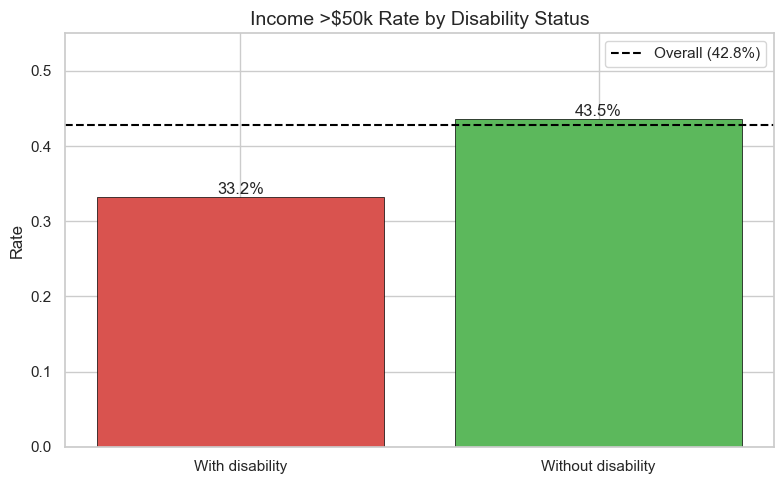

In [7]:
dis_stats = df.groupby('DIS').agg(
    count=('label', 'count'),
    income_rate=('label', 'mean')
).reset_index()
dis_stats['label_name'] = dis_stats['DIS'].map({1: 'With disability', 2: 'Without disability'})

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dis_stats['label_name'], dis_stats['income_rate'],
              color=['#d9534f', '#5cb85c'], edgecolor='black', linewidth=0.5)
ax.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Overall ({df["label"].mean():.1%})')
ax.set_title('Income >$50k Rate by Disability Status', fontsize=14)
ax.set_ylabel('Rate')
ax.set_ylim(0, 0.55)
ax.legend()
for bar, val in zip(bars, dis_stats['income_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.1%}', ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/eda/folktables_disability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Hours Worked Per Week Distribution

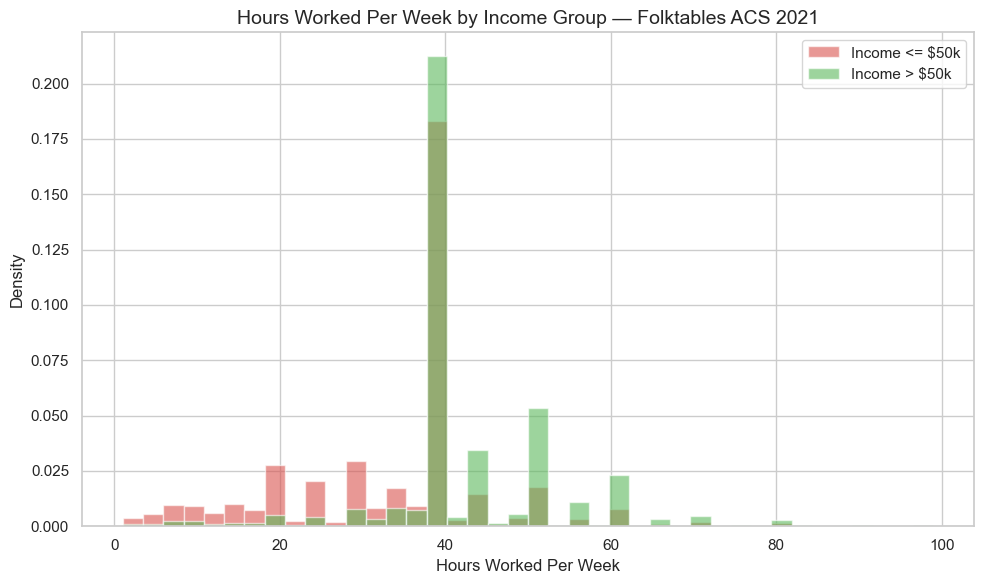

Mean hours: 38.2 | Median: 40.0
High earners mean hours: 43.0
Low earners mean hours: 34.6


In [8]:
fig, ax = plt.subplots()
ax.hist(df[df['label']==0]['WKHP'], bins=40, alpha=0.6, color='#d9534f',
        label='Income <= $50k', density=True)
ax.hist(df[df['label']==1]['WKHP'], bins=40, alpha=0.6, color='#5cb85c',
        label='Income > $50k', density=True)
ax.set_title('Hours Worked Per Week by Income Group — Folktables ACS 2021', fontsize=14)
ax.set_xlabel('Hours Worked Per Week')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/folktables_hours_worked.png', dpi=150, bbox_inches='tight')
plt.show()
wkhp_high = df[df['label']==1]['WKHP'].mean()
wkhp_low = df[df['label']==0]['WKHP'].mean()
print(f'Mean hours: {df["WKHP"].mean():.1f} | Median: {df["WKHP"].median():.1f}')
print(f'High earners mean hours: {wkhp_high:.1f}')
print(f'Low earners mean hours: {wkhp_low:.1f}')

## 7. Education Level Distribution

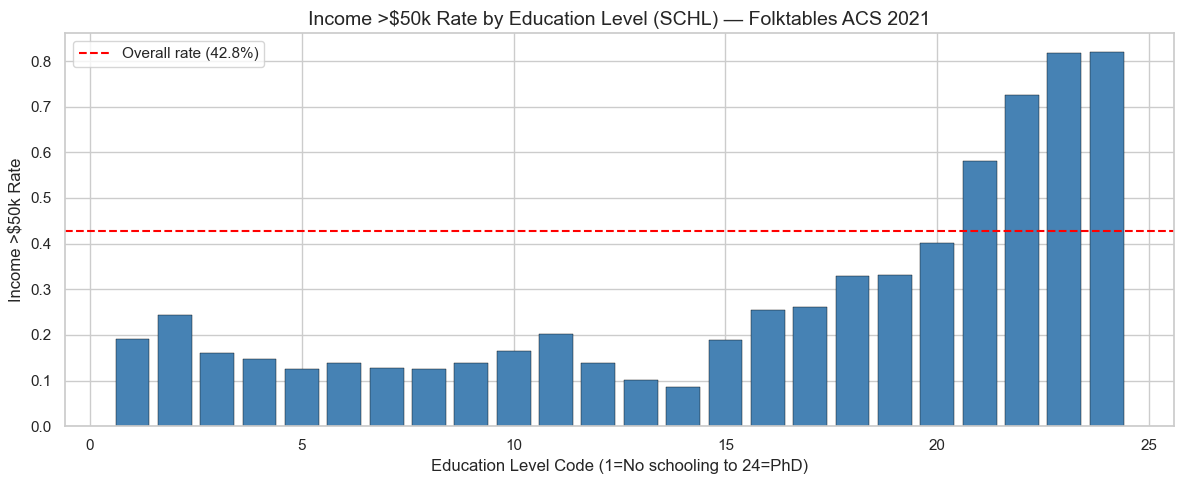

Education-income correlation: 0.321


In [9]:
schl_income = df.groupby('SCHL')['label'].mean().reset_index()
schl_income.columns = ['SCHL', 'income_rate']
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(schl_income['SCHL'], schl_income['income_rate'],
       color='steelblue', edgecolor='black', linewidth=0.3)
ax.axhline(y=df['label'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Overall rate ({df["label"].mean():.1%})')
ax.set_title('Income >$50k Rate by Education Level (SCHL) — Folktables ACS 2021', fontsize=14)
ax.set_xlabel('Education Level Code (1=No schooling to 24=PhD)')
ax.set_ylabel('Income >$50k Rate')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/folktables_education_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
edu_corr = df['SCHL'].corr(df['label'])
print(f'Education-income correlation: {edu_corr:.3f}')

## 9. Intersectional Analysis — Race × Sex Income Rate

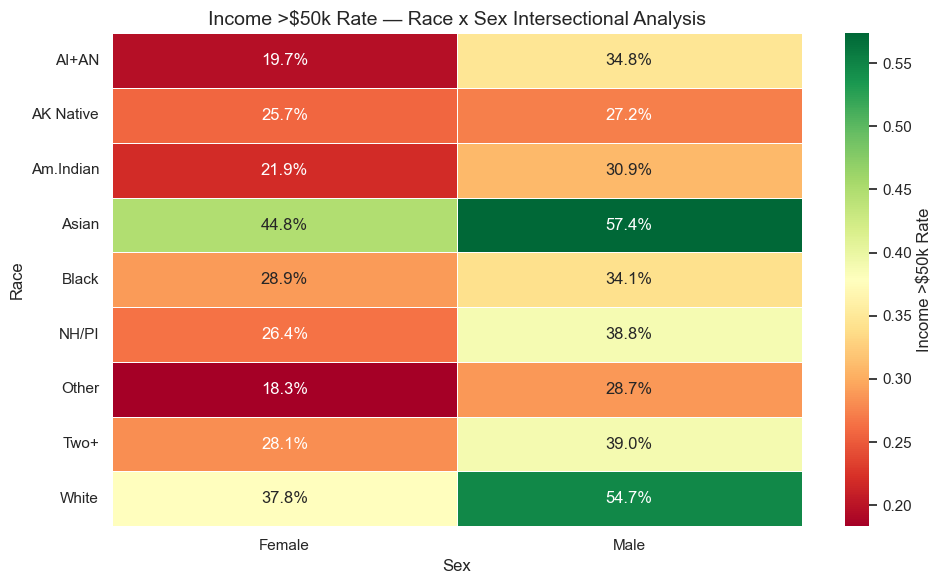

Intersectional heatmap complete


In [10]:
RACE_LABELS_SHORT = {1:'White',2:'Black',3:'Am.Indian',4:'AK Native',5:'AI+AN',6:'Asian',7:'NH/PI',8:'Other',9:'Two+'}
SEX_LABELS = {1:'Male', 2:'Female'}
df['race_label'] = df['RAC1P'].map(RACE_LABELS_SHORT)
df['sex_label'] = df['SEX'].map(SEX_LABELS)
pivot = df.groupby(['race_label','sex_label'])['label'].mean().unstack()
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn', ax=ax,
            linewidths=0.5, cbar_kws={'label':'Income >$50k Rate'})
ax.set_title('Income >$50k Rate — Race x Sex Intersectional Analysis', fontsize=14)
ax.set_xlabel('Sex')
ax.set_ylabel('Race')
plt.tight_layout()
plt.savefig('../figures/eda/folktables_intersectional_race_sex.png', dpi=150, bbox_inches='tight')
plt.show()
print('Intersectional heatmap complete')

## 10. Marital Status vs Income Rate

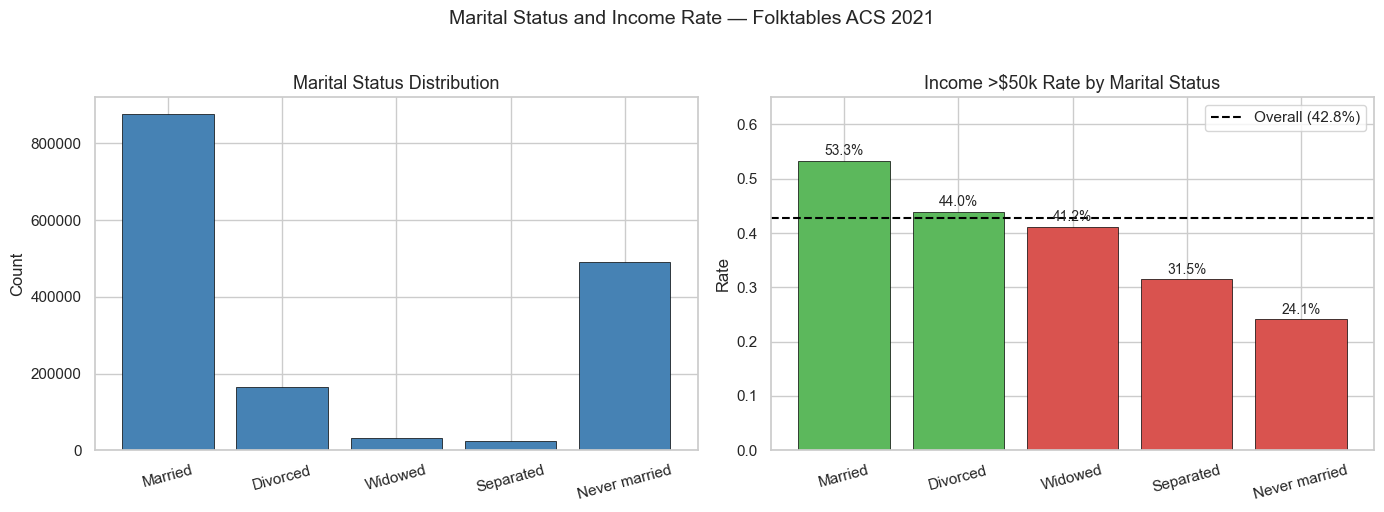

In [11]:
MAR_LABELS = {1:'Married', 2:'Widowed', 3:'Divorced', 4:'Separated', 5:'Never married'}
df['mar_label'] = df['MAR'].map(MAR_LABELS)
mar_stats = df.groupby('mar_label').agg(count=('label','count'), income_rate=('label','mean')).reset_index()
mar_stats = mar_stats.sort_values('income_rate', ascending=False)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.bar(mar_stats['mar_label'], mar_stats['count'], color='steelblue', edgecolor='black', linewidth=0.5)
ax1.set_title('Marital Status Distribution', fontsize=13)
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=15)
colors = ['#5cb85c' if r >= df['label'].mean() else '#d9534f' for r in mar_stats['income_rate']]
ax2.bar(mar_stats['mar_label'], mar_stats['income_rate'], color=colors, edgecolor='black', linewidth=0.5)
ax2.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Overall ({df["label"].mean():.1%})')
ax2.set_title('Income >$50k Rate by Marital Status', fontsize=13)
ax2.set_ylabel('Rate')
ax2.set_ylim(0, 0.65)
ax2.legend()
ax2.tick_params(axis='x', rotation=15)
for i, (_, row) in enumerate(mar_stats.iterrows()):
    ax2.text(i, row['income_rate']+0.01, f'{row["income_rate"]:.1%}', ha='center', fontsize=10)
plt.suptitle('Marital Status and Income Rate — Folktables ACS 2021', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/folktables_marital_status.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Native Born vs Foreign Born Income Rate

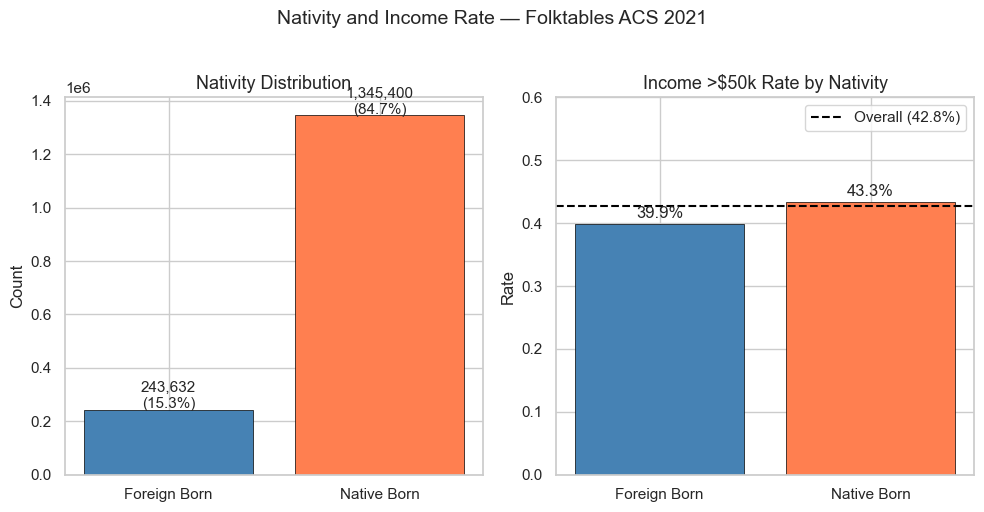

In [12]:
NATIVITY_LABELS = {1:'Native Born', 2:'Foreign Born'}
df['nativity_label'] = df['NATIVITY'].map(NATIVITY_LABELS)
nat_stats = df.groupby('nativity_label').agg(count=('label','count'), income_rate=('label','mean')).reset_index()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.bar(nat_stats['nativity_label'], nat_stats['count'], color=['steelblue','coral'], edgecolor='black', linewidth=0.5)
ax1.set_title('Nativity Distribution', fontsize=13)
ax1.set_ylabel('Count')
for i, (_, row) in enumerate(nat_stats.iterrows()):
    ax1.text(i, row['count']+5000, f'{row["count"]:,}\n({row["count"]/len(df):.1%})', ha='center', fontsize=11)
ax2.bar(nat_stats['nativity_label'], nat_stats['income_rate'], color=['steelblue','coral'], edgecolor='black', linewidth=0.5)
ax2.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Overall ({df["label"].mean():.1%})')
ax2.set_title('Income >$50k Rate by Nativity', fontsize=13)
ax2.set_ylabel('Rate')
ax2.set_ylim(0, 0.6)
ax2.legend()
for i, (_, row) in enumerate(nat_stats.iterrows()):
    ax2.text(i, row['income_rate']+0.01, f'{row["income_rate"]:.1%}', ha='center', fontsize=12)
plt.suptitle('Nativity and Income Rate — Folktables ACS 2021', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/folktables_nativity.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Income to Poverty Ratio (POVPIP) Distribution

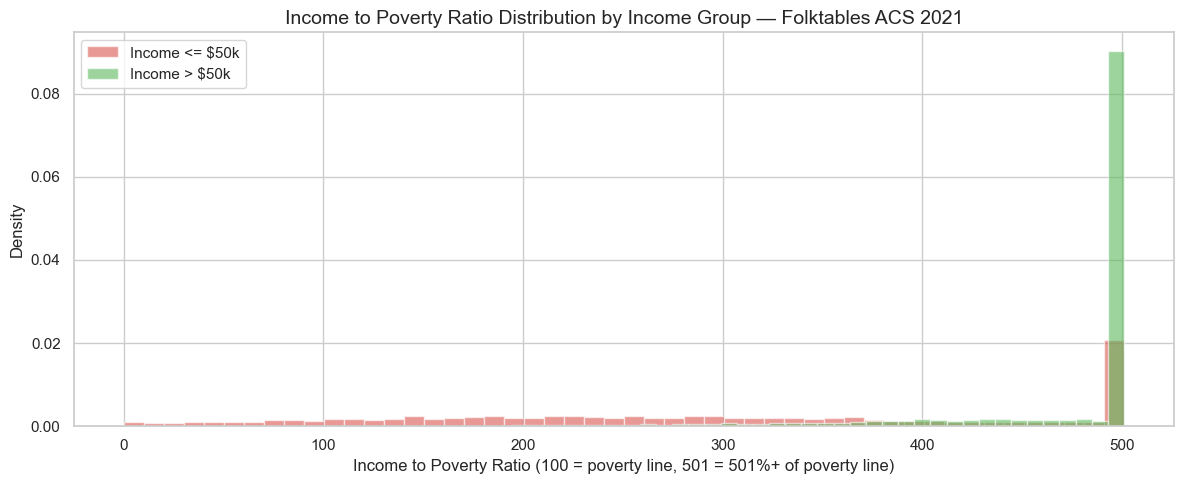

Poverty ratio mean: 372.1 | Median: 434.0
Below poverty line (POVPIP<100): 93,523 (5.9%)


In [13]:
fig, ax = plt.subplots(figsize=(12,5))
ax.hist(df[df['label']==0]['POVPIP'], bins=50, alpha=0.6, color='#d9534f', label='Income <= $50k', density=True)
ax.hist(df[df['label']==1]['POVPIP'], bins=50, alpha=0.6, color='#5cb85c', label='Income > $50k', density=True)
ax.set_title('Income to Poverty Ratio Distribution by Income Group — Folktables ACS 2021', fontsize=14)
ax.set_xlabel('Income to Poverty Ratio (100 = poverty line, 501 = 501%+ of poverty line)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/folktables_poverty_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Poverty ratio mean: {df["POVPIP"].mean():.1f} | Median: {df["POVPIP"].median():.1f}')
print(f'Below poverty line (POVPIP<100): {(df["POVPIP"]<100).sum():,} ({(df["POVPIP"]<100).mean():.1%})')

## 13. Feature-Label Correlation

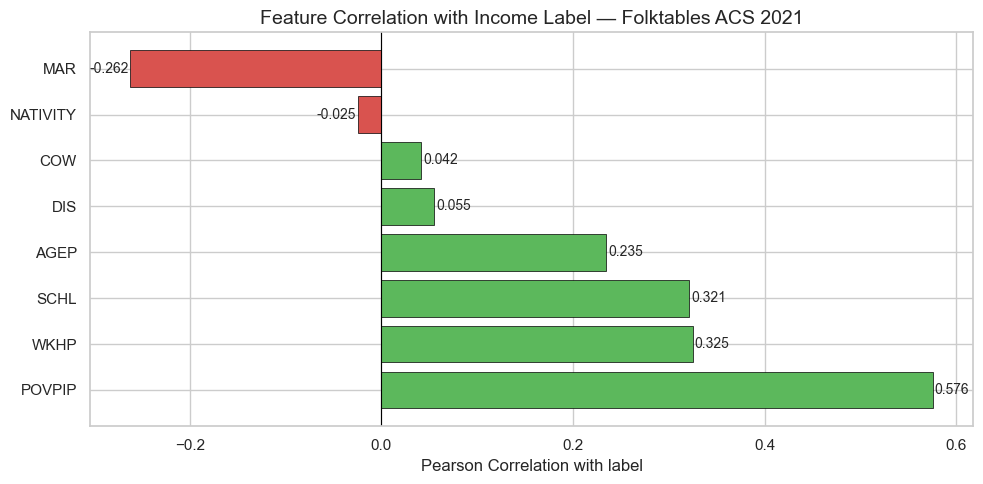

Feature correlations:
  POVPIP       0.576
  WKHP         0.325
  SCHL         0.321
  AGEP         0.235
  DIS          0.055
  COW          0.042
  NATIVITY     -0.025
  MAR          -0.262


In [14]:
numeric_cols = ['AGEP','SCHL','MAR','WKHP','COW','DIS','POVPIP','NATIVITY']
correlations = df[numeric_cols + ['label']].corr()['label'].drop('label').sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10,5))
colors = ['#5cb85c' if c > 0 else '#d9534f' for c in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Income Label — Folktables ACS 2021', fontsize=14)
ax.set_xlabel('Pearson Correlation with label')
for i, (feat, val) in enumerate(correlations.items()):
    ax.text(val + 0.002 if val >= 0 else val - 0.002, i,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/eda/folktables_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature correlations:')
for feat, val in correlations.items():
    print(f'  {feat:<12} {val:.3f}')

## 14. Key Fairness Observations

**Race gap:** White income rate (46.7%) vs Black/African-American (31.3%) = **15.4% gap**  
**Sex gap:** Male (49.8%) vs Female (35.1%) = **14.6% gap**  
**Disability gap:** Without disability (43.5%) vs With disability (33.2%) = **10.3% gap**  
**Asian exception:** Asian income rate (51.1%) exceeds White rate — important for intersectional analysis  

These raw gaps do not imply algorithmic bias — they reflect structural inequality in the underlying data.
FAPE Stage 2 will compute formal fairness metrics (demographic parity, equalized odds, disparate impact)
to quantify what a model trained on this data would inherit.
